# Task 1: Diagnostic Enhancement of Chest X-Rays


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title, cmap='gray'):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

## 1. Load and Display

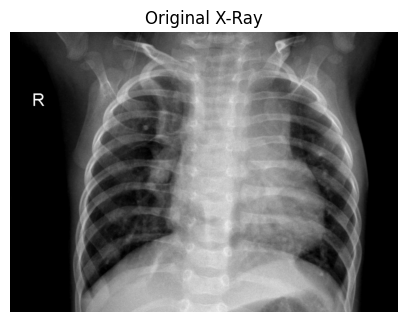

In [14]:
img = cv2.imread('data/sample_xray.jpeg', cv2.IMREAD_GRAYSCALE)
show(img, 'Original X-Ray')

## 2. Contrast Enhancement (Histogram Equalization)

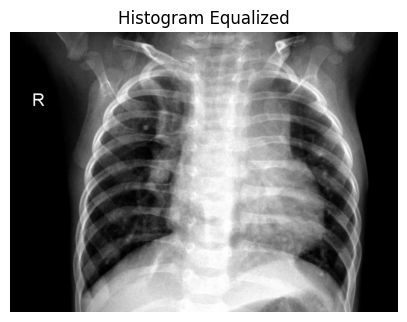

In [15]:
equalized = cv2.equalizeHist(img)
show(equalized, 'Histogram Equalized')

## 3. Color Mapping (Heatmap)

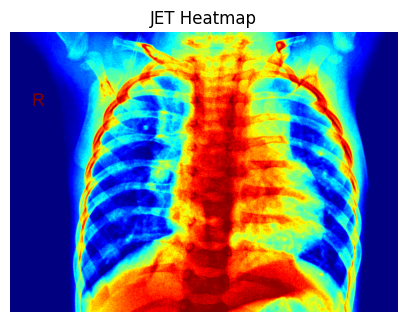

In [16]:
heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
show(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB), 'JET Heatmap', cmap=None)

## 4. Color Balance

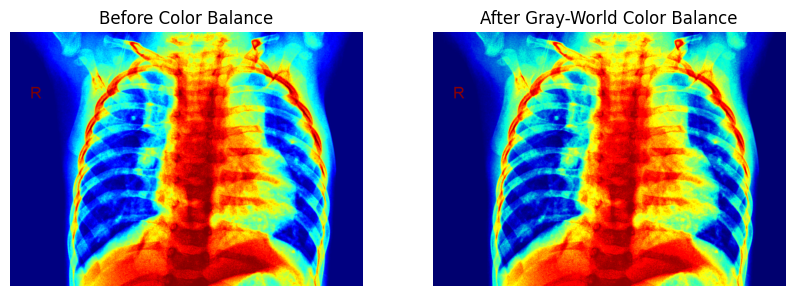

In [12]:
import os

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def gray_world_balance(bgr_image):
    b, g, r = cv2.split(bgr_image.astype(np.float64))
    gray_mean = (b.mean() + g.mean() + r.mean()) / 3.0
    b_gain = gray_mean / (b.mean() + 1e-6)
    g_gain = gray_mean / (g.mean() + 1e-6)
    r_gain = gray_mean / (r.mean() + 1e-6)
    balanced_b = np.clip(b * b_gain, 0, 255)
    balanced_g = np.clip(g * g_gain, 0, 255)
    balanced_r = np.clip(r * r_gain, 0, 255)
    return cv2.merge([balanced_b, balanced_g, balanced_r]).astype(np.uint8)

balanced = gray_world_balance(heatmap)
balanced_rgb = cv2.cvtColor(balanced, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
axes[0].set_title('Before Color Balance')
axes[0].axis('off')
axes[1].imshow(balanced_rgb)
axes[1].set_title('After Gray-World Color Balance')
axes[1].axis('off')
plt.savefig(os.path.join(OUTPUT_DIR, 'balanced.png'), bbox_inches='tight')
plt.show()


## 5. Color Filtering / Thresholding

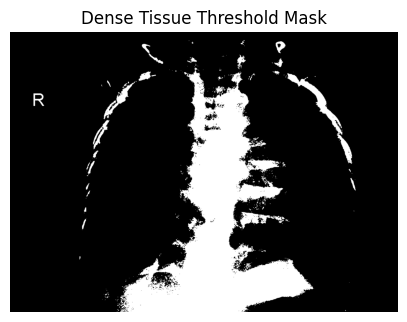

In [17]:
_, thresh = cv2.threshold(equalized, 200, 255, cv2.THRESH_BINARY)
show(thresh, 'Dense Tissue Threshold Mask')

## 6. Logarithmic Transformation

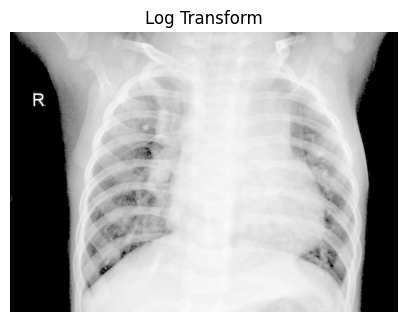

In [18]:
img_f = img.astype(np.float32) + 1
c = 255 / np.log(1 + np.max(img_f))
log_img = (c * np.log(img_f)).astype(np.uint8)
show(log_img, 'Log Transform')

## 7. Power-Law (Gamma) Transformation

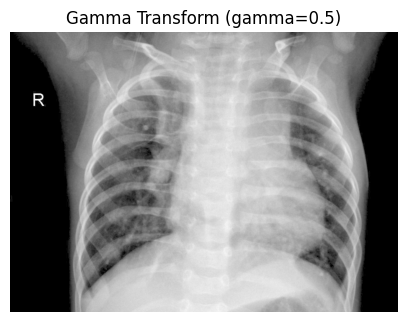

In [19]:
gamma = 0.5  # gamma < 1.0 brightens midtones
norm = img.astype(np.float32) / 255.0
gamma_img = (np.power(norm, gamma) * 255).astype(np.uint8)
show(gamma_img, f'Gamma Transform (gamma={gamma})')

## Save outputs

In [13]:
cv2.imwrite('output/equalized.png', equalized)
cv2.imwrite('output/heatmap.png', heatmap)
cv2.imwrite('output/threshold.png', thresh)
cv2.imwrite('output/balanced.png', balanced)
cv2.imwrite('output/log_transform.png', log_img)
cv2.imwrite('output/gamma_transform.png', gamma_img)
print('Saved all outputs to output/')

Saved all outputs to output/


In [ ]:
import os

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save every image that was shown during the notebook workflow
cv2.imwrite(os.path.join(OUTPUT_DIR, 'original_xray.png'), img)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'equalized.png'), equalized)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'heatmap.png'), heatmap)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'threshold.png'), thresh)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'log_transform.png'), log_img)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'gamma_transform.png'), gamma_img)
cv2.imwrite(os.path.join(OUTPUT_DIR, 'balanced.png'), balanced)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
axes[0].set_title('Before Color Balance')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(balanced, cv2.COLOR_BGR2RGB))
axes[1].set_title('After Gray-World Color Balance')
axes[1].axis('off')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'balanced_comparison.png'), bbox_inches='tight')
plt.close(fig)

print(f'Saved all displayed notebook images to {os.path.abspath(OUTPUT_DIR)}/')
